Этот пункт предполагает использование простой линейной регрессии применительно к набору данных Auto.
(a) Воспользуйтесь функцией sm.OLS() для построения простой линейной регрессии с переменной mpg в качестве отклика и horsepower в  качестве предиктора. Вызовите функцию summarize()
для вывода результата. Прокомментируйте результирующие
данные, например на основе следующих вопросов:

In [73]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm

Auto = pd.read_csv('data/Auto.csv')
X = pd.DataFrame({'intercept': np.ones(Auto.shape[0]),
                                       'horsepower': Auto['horsepower']})
y = Auto['mpg']

model = sm.OLS(y, X).fit()
summarize(model)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i) существует ли зависимость между предиктором и откликом?


Да существует (низкое р-значение)

ii) насколько сильна зависимость между предиктором и откликом?


Зависимость достаточно сильная учитывая среднее значение числа лошадиных сил

iii) является ли зависимость между предиктором и откликом
положительной или отрицательной?


Отрицательной

In [52]:
# iv) каким будет значение отклика mpg для значения предиктора horsepower, равного 98? Какими будут 95-процентные
# доверительный интервал и интервал предсказания?
prediction = model.get_prediction([[1, 98]])
print('Predicted value =', prediction.predicted_mean[0])
print('Confidence interval =', prediction.conf_int(alpha=0.05)[0])
print('Confidence interval obs =', prediction.conf_int(alpha=0.05, obs=True)[0])

Predicted value = 24.467077152512424
Confidence interval = [23.97307896 24.96107534]
Confidence interval obs = [14.80939607 34.12475823]


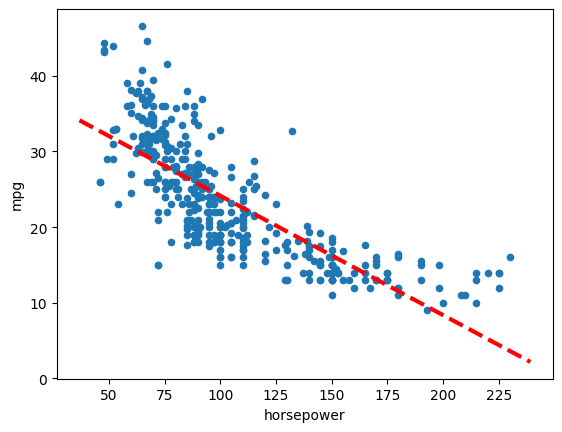

In [78]:
# (b) Постройте график зависимости предиктора и  отклика с  использованием нового объекта ax. Воспользуйтесь методом
# ax.axline() или функцией abline(), показанной в лабораторной
# работе, для отображения регрессионной линии, найденной по
# методу наименьших квадратов.
ax = Auto.plot.scatter('horsepower', 'mpg')

intercept = model.params.intercept
slope = model.params.horsepower

xlim = ax.get_xlim()
ylim = [slope * xlim[0] + intercept, slope * xlim[1] + intercept]

ax.plot(xlim, ylim, 'r--', linewidth=3)

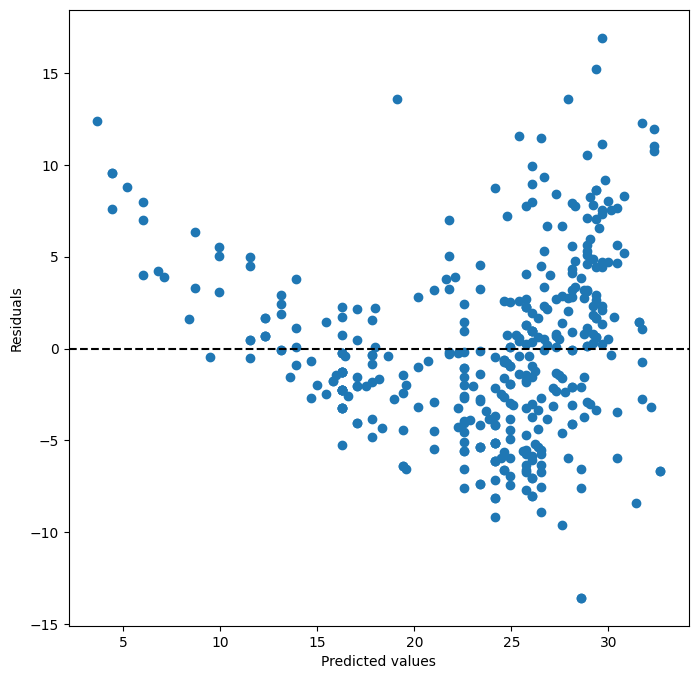

In [81]:
# (c) Постройте несколько диагностических графиков на основе регрессии по методу наименьших квадратов, как было показано
# в  лабораторной работе. Опишите проблемы, обнаруженные
# в этой модели.
ax = subplots(figsize=(8,8))[1]
ax.scatter(model.fittedvalues, model.resid)
ax.set_xlabel('Predicted values')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--')

На графике выше есть некая тенденция в форме параболы, что свидетельствует о нелинейности связи между переменной и откликом.

115

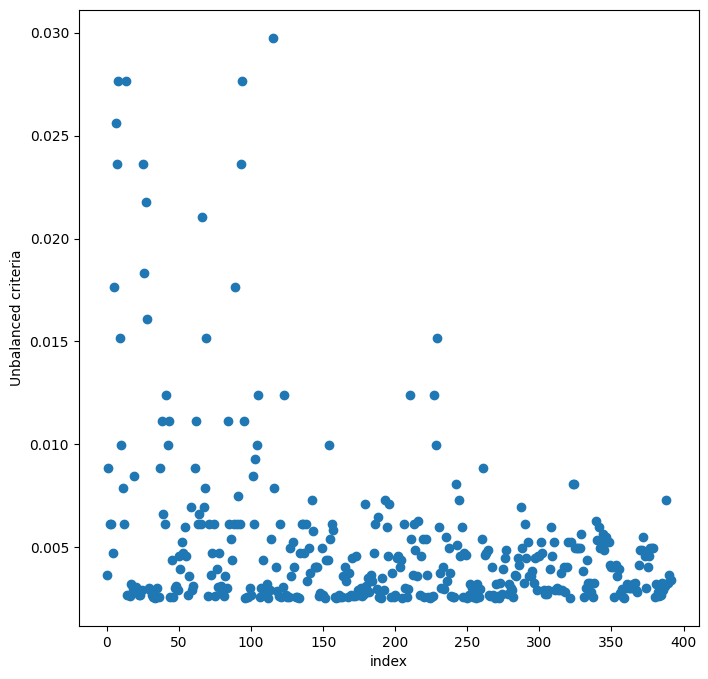

In [82]:
infl = model.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('index')
ax.set_ylabel('Unbalanced criteria')
np.argmax(infl.hat_matrix_diag)

Касательно разбалансировки, я конечно не эксперт по данным, но какого-то конкретного аутлаера не вижу, скорее речь идет о группе наблюдений,
которая выделяется из общей массы.